In [3]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize 
from nltk.corpus import stopwords, inaugural
from nltk.text import Text 
from nltk.draw.dispersion import dispersion_plot
from nltk.probability import FreqDist
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder
from nltk.tag import pos_tag
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import string 
import re

<h4> Zadanie1: Jak sprawdzić czy zadany ciąg tekstowy jest liczbą? Przykładowo '1', '12.3', '50,25' uznajemy za liczby, a '1a' już nie. Napisz odpowiednią funkcję, która zwraca wartość logiczną True lub False.

In [4]:
def is_num (string):
    temp = [".", ",", "-", "+"]
    for i in temp:
        string = string.replace(i, "")
    return string.isnumeric()

print(is_num("1a"))

False


<h4> Zadanie2: Wyświetl wszystkie konteksty słowa $death$.

In [4]:
file = open('example_text.txt','r')  
text = file.read().replace('\n','')
file.close()
txt_words = word_tokenize(text)
txt_words = [word.lower() for word in txt_words]   
t = Text(txt_words)

print(t.concordance('death'))

Displaying 6 of 6 matches:
hen hindus , at places where , after death , their remains may without difficul
teristic marks of leprosy , and that death took place seven years afterwards . 
this stage for years , and even till death of the patient , or the disease adva
s look older than they usually are . death generally takes place from diarrha a
e not leprous . after her husband 's death she came to live with her brother , 
n returned home after her husband 's death he had not seen a leper in that vill
None


<h4> Zadanie3: Narysuj analogiczny wykres jak wyżej, z tym że tym razem nie uwzględniaj stop words, znaków interpunkcyjnych i liczb. Zapisz te wybrane tokeny do listy o nazwie  filtered_words .

<Axes: title={'center': 'Rozkład występowania 30 najpopularniejszych tokenów'}, xlabel='Samples', ylabel='Counts'>

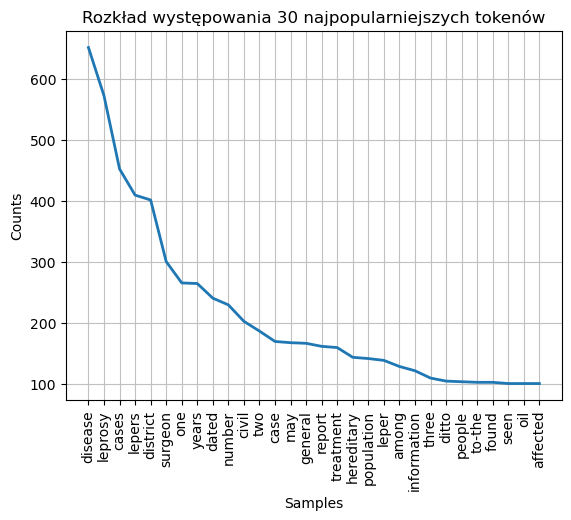

In [26]:
stop_words =  set(stopwords.words("english"))

def inter (word): #funkcja do odfiltrowania wielokrotności interpunkcji
    return re.sub(rf"^[{re.escape(string.punctuation)}]+|[{re.escape(string.punctuation)}]+$", "", word)

filtered_words = [elem for elem in txt_words if inter(elem) and not is_num(elem) and elem not in stop_words]
test = FreqDist(filtered_words)

test.plot(30,title='Rozkład występowania 30 najpopularniejszych tokenów')

<h4> Zadanie4: Wykonaj analogiczną analize jak wyżej, z tym że nie bierz pod uwagę stop words, znaków interpunkcyjnych ani liczb przy szukaniu kolokacji.

In [28]:
bigram_measures = BigramAssocMeasures()
finder = BigramCollocationFinder.from_words(filtered_words, 5) #przefiltrowana lista słów z zadania powyżej
finder.apply_freq_filter(10)
finder.nbest(bigram_measures.likelihood_ratio, 15)

[('ditto', 'ditto'),
 ('civil', 'surgeon'),
 ('gurjun', 'oil'),
 ('surgeon', 'general'),
 ('deputy', 'circle'),
 ('deputy', 'general'),
 ('years', 'years'),
 ('number', 'lepers'),
 ('sanitary', 'commissioner'),
 ('deputy', 'surgeon'),
 ('general', 'circle'),
 ('surgeon', 'circle'),
 ('circular', 'memorandum'),
 ('hereditary', 'taint'),
 ('m.', 'd.')]

<h4> Zadanie5: Przeanalizuj ponownie korpus  inaugural. <br>
    
  - zapisz wszystkie tokeny z wszystkich dokumentów do jednej listy ($inaugural\_tokens=inaugural.words()$)

In [5]:
inaugural_tokens = inaugural.words()

- zmień wszystkie litery na małe

In [6]:
inaugural_tokens = [word.lower() for word in inaugural_tokens]

- ile występuje unikatowych tokenów?

In [13]:
fdist = FreqDist(inaugural_tokens)
ilosc = 0
unikatowe = []
for i in fdist:
    if fdist[i] == 1:
        ilosc += 1
        unikatowe.append(i)

print(f"Jest {ilosc} unikatowych tokenów w przemówieniach inauguracyjnych.")

Jest 3894 unikatowych tokenów w przemówieniach inauguracyjnych.


- wyznacz 7 najczęstszych kolokacji występujących co najmniej 10 razy nie zawierających stop words, znaków interpunkcyjncyh, liczb (dopuszczamy okno 5)

In [71]:
bigram_measures = BigramAssocMeasures()
filtracja = [elem for elem in inaugural_tokens if inter(elem) and not is_num(elem) and elem not in stop_words]
finder = BigramCollocationFinder.from_words(filtracja, 5)
finder.apply_freq_filter(10)
print(f"Siedem najczęstszych kolokacji: {finder.nbest(bigram_measures.likelihood_ratio, 7)}.")

Siedem najczęstszych kolokacji: [('united', 'states'), ('fellow', 'citizens'), ('let', 'us'), ('thank', 'thank'), ('one', 'another'), ('men', 'women'), ('four', 'years')].


- wykonaj metode $nltk.pos\_tag$ na liście unikatowych tokenów i zapisz wyniki pod nazwą $tagged\_inaugural\_tokens$
zapisz do listy $nouns$ tylko te tokeny z $inaugural\_tokens$, które są rzeczownikami (tag NN lub NNs)

In [14]:
tagged_inaugural_tokens = nltk.pos_tag(unikatowe)
nouns = [word for word, tag in nltk.pos_tag(inaugural_tokens) if tag == 'NN' or tag == 'NNS']

- jakie trzy rzeczowniki pojawiały się najczęściej?

In [22]:
rzecz_fdist = FreqDist(nouns)
targets = [word for word, number in rzecz_fdist.most_common(3)]
print(f"Trzy najczestsze rzeczowniki to {targets}.")

Trzy najczestsze rzeczowniki to ['government', 'people', 'i'].


- narysuj wykres rozkładu tych trzech rzeczowników w kolejnych latach

<Axes: title={'center': 'Rozkład trzech najpopularniejszych rzeczowników w czasie'}, xlabel='Samples', ylabel='Counts'>

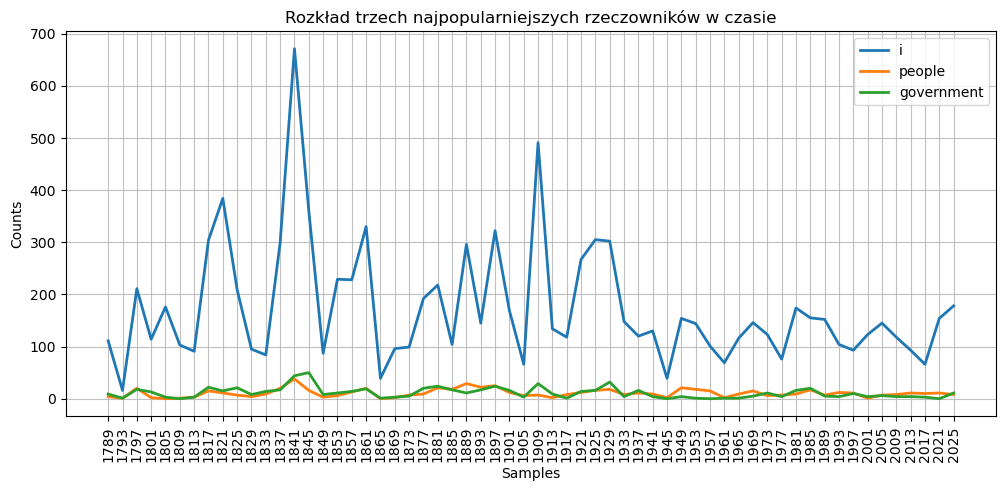

In [74]:
plt.rcParams["figure.figsize"] = (12, 5) 

cfd = nltk.ConditionalFreqDist((target, fileid[:4]) #fieleid[:4] jest po to zeby na rysnku pokazywal tylko pierwsze cztery znaki z nazwy (czyli rok)
    for fileid in inaugural.fileids() #dla kolejnych plikow
    for word in inaugural.words(fileid) #dla kolejnych slow w tych plikach
    for target in targets #dla kazdego slowa z listy zadanych przez nas
    if word.lower().startswith(target)) #czy slowo w tekscie zaczyna sie od naszego slowa targetu?
cfd.plot(title = "Rozkład trzech najpopularniejszych rzeczowników w czasie")

- narysuj wykres typu  wordcloud  dla wszystkich rzeczowników

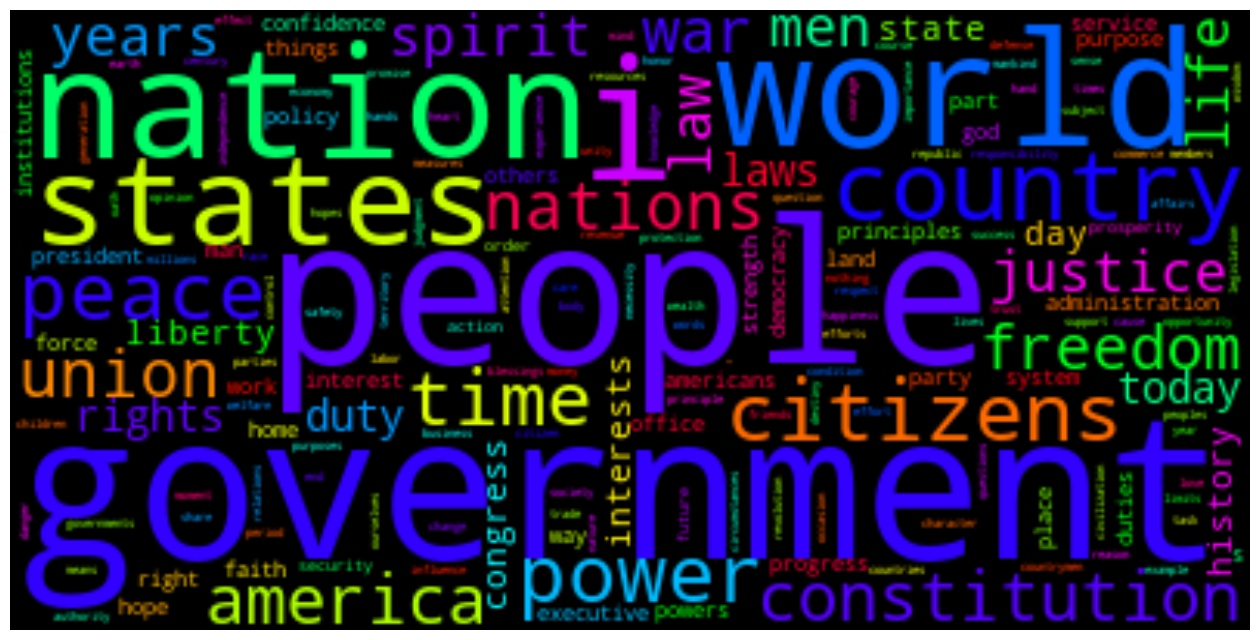

In [75]:
cloud = WordCloud(max_font_size=80,colormap="hsv").generate_from_frequencies(rzecz_fdist)
plt.figure(figsize=(16,12)) #wymiar obrazka
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off')
plt.show()

- jakie trzy przymiotniki w stopniu wyższym i najwyższym występowały najczęściej we wszystkich przemowach? (tag JJR/JJS)

In [26]:
wyzszy = [word for word, tag in nltk.pos_tag(inaugural_tokens) if tag == 'JJR']
najwyzszy = [word for word, tag in nltk.pos_tag(inaugural_tokens) if tag == 'JJS']

wyzszy_fdist = FreqDist(wyzszy)
najwyzszy_fdist = FreqDist(najwyzszy)

tri_wyzsze = [word for word, number in wyzszy_fdist.most_common(3)]
tri_najwyzsze = [word for word, number in najwyzszy_fdist.most_common(3)]
print(f"Trzy najczęstsze przymiotniki w stopniu wyższym to {tri_wyzsze}, natomiast trzy najczęstsze przymiotniki w stopniu najwyższym to {tri_najwyzsze}.")

Trzy najczęstsze przymiotniki w stopniu wyższym to ['more', 'better', 'greater'], natomiast trzy najczęstsze przymiotniki w stopniu najwyższym to ['best', 'greatest', 'highest'].


- zobacz jak wygląda rozkład występowania słowa  war  w całym korpusie (lexical dispersion plot)

<Axes: title={'center': 'Rozkład wystepowania słowa war w całym korpusie'}, xlabel='Word Offset'>

<Figure size 1200x900 with 0 Axes>

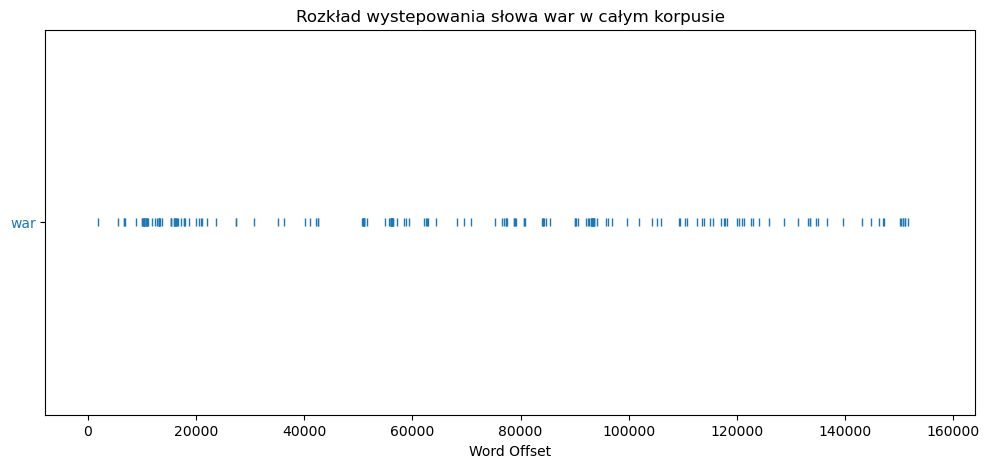

In [81]:
plt.figure(figsize=(12, 9))
inaugural_texts = Text(inaugural_tokens)
dispersion_plot(inaugural_texts, ["war"] , ignore_case=True, title='Rozkład wystepowania słowa war w całym korpusie')